Population size: 21


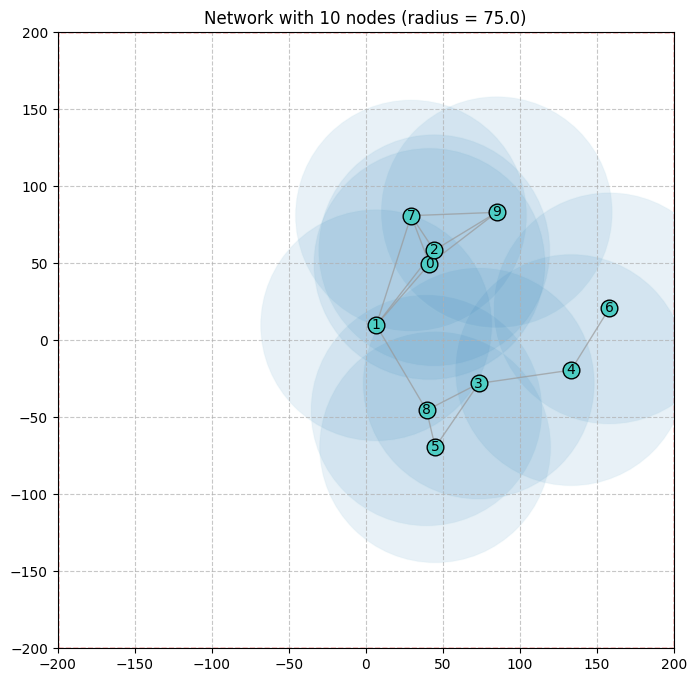

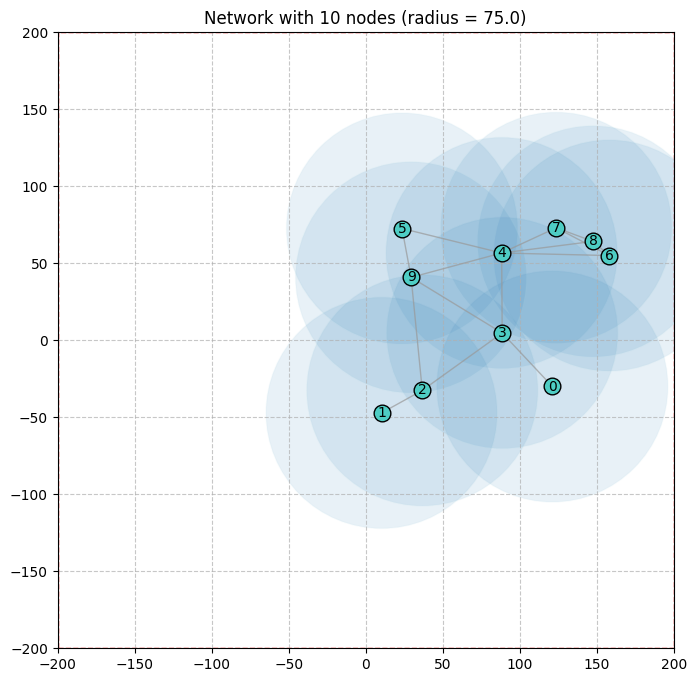

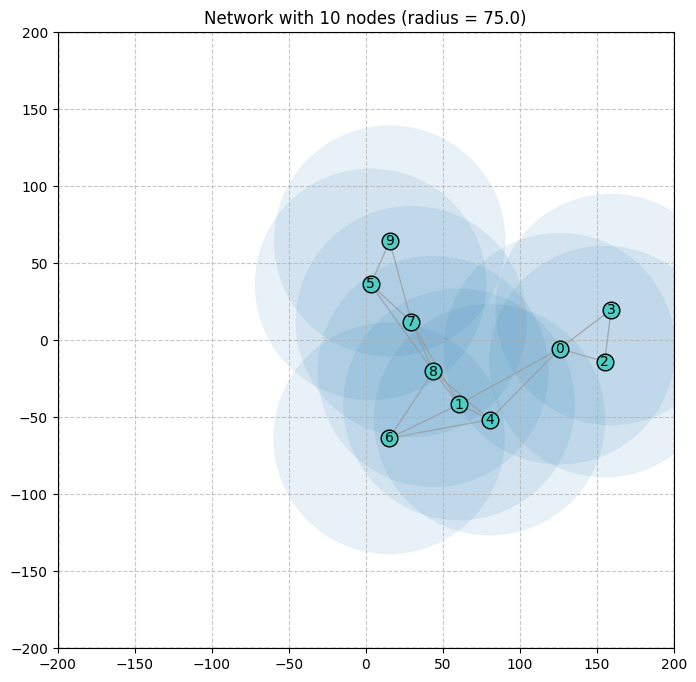

In [13]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from collections import defaultdict

# ============================================================
# Plot fornecido
# ============================================================

def plot_network(points, region, radius):
    _, ax = plt.subplots(figsize=(10, 8))

    ax.set_xlim(region[0], region[2])
    ax.set_ylim(region[1], region[3])
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_title(f'Network with {len(points)} nodes (radius = {radius})')

    rect = plt.Rectangle(
        (region[0], region[1]),
        region[2] - region[0],
        region[3] - region[1],
        fill=False,
        linestyle='--',
        edgecolor='red',
        linewidth=1
    )
    ax.add_patch(rect)

    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            d = np.hypot(
                points[i][0] - points[j][0],
                points[i][1] - points[j][1]
            )
            if d <= radius:
                ax.plot(
                    [points[i][0], points[j][0]],
                    [points[i][1], points[j][1]],
                    color='#999999',
                    linewidth=1,
                    alpha=0.7
                )

    for (x, y) in points:
        circle = Circle((x, y), radius,
                        fill=True, alpha=0.1,
                        edgecolor='lightblue', linewidth=1)
        ax.add_patch(circle)

    for i, (x, y) in enumerate(points):
        ax.plot(x, y, 'o', markersize=12,
                color='#4ECDC4',
                markeredgecolor='black')
        ax.text(x, y, str(i),
                color='black',
                ha='center',
                va='center')

    plt.show()


# ============================================================
# Parâmetros do espaço de busca
# ============================================================

XL = np.tile([-10.0, -70.0], 10)
XU = np.tile([190.0,  90.0], 10)

SINK = (62.84, 1.66)
MAX_DISTANCE = 75.0
MAX_CHILDREN = 3


# ============================================================
# Utilidades genéticas
# ============================================================

def generate_individual(rng: random.Random) -> list[float]:
    """
    Geração contínua uniforme (essência do create_individual).
    """
    genes = []

    for i in range(len(XL)):
        v = rng.uniform(XL[i], XU[i])
        v = round(v, 2)  # mesma discretização do código original
        genes.append(v)

    # evita degeneração trivial (0,0)
    for i in range(0, len(genes), 2):
        if genes[i] == 0.0:
            genes[i] += 0.01
        if genes[i + 1] == 0.0:
            genes[i + 1] += 0.01

    return genes


def genes_to_points(ind):
    return [(ind[i], ind[i + 1]) for i in range(0, len(ind), 2)]


# ============================================================
# Validação topológica (DODAG simplificado)
# ============================================================

def euclidean(a, b):
    return float(np.hypot(a[0] - b[0], a[1] - b[1]))


def dodag_feasible(points):
    """
    Versão abstrata da simulate_organize_into_dodag.
    """

    processed = [SINK]
    children = defaultdict(list)
    children[SINK] = []

    for node in points:

        best_parent = None
        best_dist = float("inf")

        for p in processed:
            if len(children[p]) < MAX_CHILDREN:
                d = euclidean(node, p)
                if d < best_dist:
                    best_parent = p
                    best_dist = d

        if best_parent is None or best_dist > MAX_DISTANCE:
            return False

        processed.append(node)
        children[node] = []
        children[best_parent].append(node)

    return True


# ============================================================
# Reparo / regeneração
# ============================================================

def repair_or_regenerate(ind, rng, max_attempts=5):
    """
    Essência do loop de regeneração do seu código.
    """

    for _ in range(max_attempts):

        pts = genes_to_points(ind)

        if dodag_feasible(pts):
            return ind  # válido

        # Regenera parcialmente (mutação forte)
        for i in range(len(ind)):
            if rng.random() < 0.3:
                ind[i] = round(rng.uniform(XL[i], XU[i]), 2)

    return None  # falhou


# ============================================================
# Gerador populacional (21 indivíduos válidos)
# ============================================================

def generate_population(
    n_individuals=21,
    seed=42
):

    rng = random.Random(seed)

    population = []
    signatures = set()

    while len(population) < n_individuals:

        ind = generate_individual(rng)
        ind = repair_or_regenerate(ind, rng)

        if ind is None:
            continue

        sig = tuple(ind)
        if sig in signatures:
            continue

        signatures.add(sig)
        population.append(ind)

    return population


# ============================================================
# Execução demo
# ============================================================

if __name__ == "__main__":

    REGION = (-200.0, -200.0, 200.0, 200.0)
    RADIUS = 75.0

    pop = generate_population(21, seed=7)

    print(f"Population size: {len(pop)}")

    # Plotar alguns indivíduos
    for i in range(3):
        points = genes_to_points(pop[i])
        plot_network(points, REGION, RADIUS)
